In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import spearmanr



In [2]:
ROOT = Path.cwd().parent
DATA_PATH = ROOT / 'data'

DATA_PATH



PosixPath('/Users/romacarapetean/Desktop/Projects/University/MLPC2026/data')

In [3]:
npz_path = DATA_PATH / 'audio_features' / '000078.npz'

# Extract a single npz file and print its contents
with np.load(npz_path, allow_pickle=True) as data:
    print(f"File: {npz_path.name}")
    print(f"Keys ({len(data.files)}): {data.files}\n")
    for key in data.files:
        value = data[key]
        print(f"{key}:")
        print(f"  shape={value.shape}, dtype={value.dtype}")
        if value.size <= 10:
            print(f"  values={value}")
        else:
            flat = value.ravel()
            print(f"  first 10 values={flat[:10]}")
        print()

File: 000078.npz
Keys (68): ['zcr_mean', 'zcr_std', 'zcr_min', 'zcr_max', 'start_time', 'end_time', 'melspect_mean', 'melspect_std', 'melspect_min', 'melspect_max', 'mfcc_mean', 'mfcc_std', 'mfcc_min', 'mfcc_max', 'mfcc_d_mean', 'mfcc_d_std', 'mfcc_d_min', 'mfcc_d_max', 'mfcc_d2_mean', 'mfcc_d2_std', 'mfcc_d2_min', 'mfcc_d2_max', 'flux_mean', 'flux_std', 'flux_min', 'flux_max', 'flatness_mean', 'flatness_std', 'flatness_min', 'flatness_max', 'centroid_mean', 'centroid_std', 'centroid_min', 'centroid_max', 'bandwidth_mean', 'bandwidth_std', 'bandwidth_min', 'bandwidth_max', 'contrast_mean', 'contrast_std', 'contrast_min', 'contrast_max', 'rolloff_low_mean', 'rolloff_low_std', 'rolloff_low_min', 'rolloff_low_max', 'rolloff_high_mean', 'rolloff_high_std', 'rolloff_high_min', 'rolloff_high_max', 'energy_mean', 'energy_std', 'energy_min', 'energy_max', 'power_mean', 'power_std', 'power_min', 'power_max', 'annotations', 'is_own_recording', 'class_names', 'annotator_ids', 'target_classes', 'n

In [4]:
feature_dir = Path.cwd().parent / "data" / "audio_features"
npz_files = sorted(feature_dir.glob("*.npz"))

exclude_keys = {
    "start_time", "end_time", "annotations", "is_own_recording",
    "class_names", "annotator_ids", "target_classes", "non_target_classes",
    "recording_device", "recording_environments", "scene_description",
    "device_placement"
}

all_values = {}

for file in npz_files:
    with np.load(file, allow_pickle=True) as data:
        for key in data.files:
            if key in exclude_keys:
                continue
            
            arr = data[key]
            if not np.issubdtype(arr.dtype, np.number):
                continue

            all_values.setdefault(key, []).append(arr.astype(float).ravel())

summary_rows = []

for key, chunks in all_values.items():
    values = np.concatenate(chunks)
    summary_rows.append({
        "feature": key,
        "mean": values.mean(),
        "std": values.std(),
        "min": values.min(),
        "max": values.max(),
        "range": values.max() - values.min()
    })

feature_summary = pd.DataFrame(summary_rows).sort_values("feature")
feature_summary.round(4)


,feature,mean,std,min,max,range
35,bandwidth_max,3404.2932,501.8532,0.0000,4951.6614,4951.6614
32,bandwidth_mean,2784.8472,518.9174,0.0000,4359.9744,4359.9744
34,bandwidth_min,2119.9490,642.8652,0.0000,3944.7943,3944.7943
33,bandwidth_std,289.6583,175.7630,0.0000,1872.7530,1872.7530
31,centroid_max,3355.2763,1072.7912,0.0000,7615.9776,7615.9776
28,centroid_mean,2207.0094,884.1986,0.0000,5788.9517,5788.9517
30,centroid_min,1354.6654,828.6408,0.0000,5129.3805,5129.3805
29,centroid_std,450.2543,259.6398,0.0000,2641.4163,2641.4163
39,contrast_max,27.0520,11.5389,3.3587,80.1071,76.7484
36,contrast_mean,15.7409,11.1985,2.5131,67.3213,64.8082


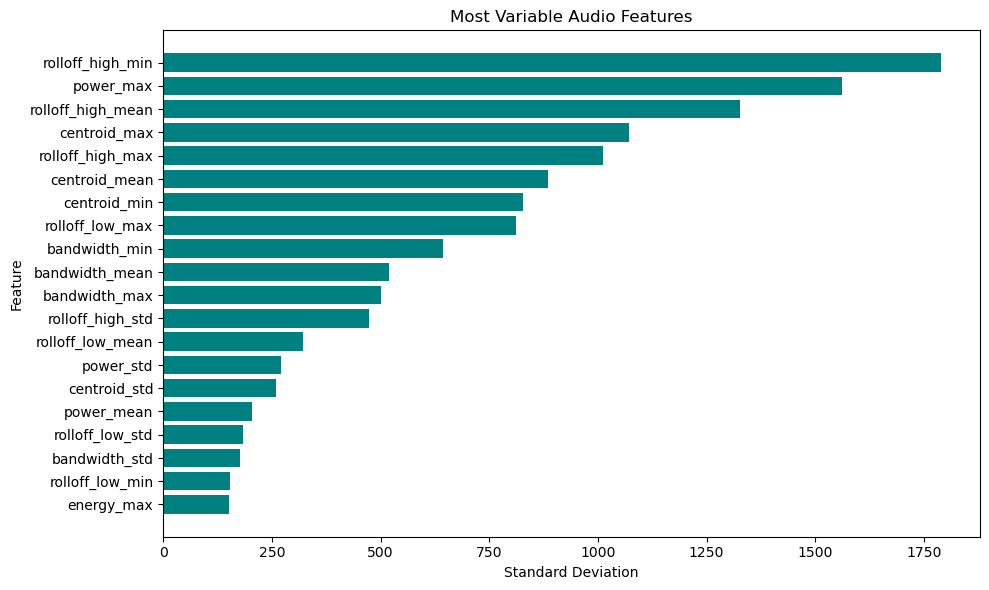

In [5]:
import matplotlib.pyplot as plt

plot_df = feature_summary.sort_values("std", ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["feature"], plot_df["std"], color="teal")
plt.xlabel("Standard Deviation")
plt.ylabel("Feature")
plt.title("Most Variable Audio Features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [6]:
feature_dir = Path.cwd().parent / "data" / "audio_features"
npz_files = sorted(feature_dir.glob("*.npz"))


melspect_vals = []
mfcc_vals = []


for file in npz_files:
    with np.load(file, allow_pickle=True) as data:
        # take the mean per file and add the value to the list
        # we do this because features have different shapes
        # For ex [T, 32] [T, 1], [T, 128] so we can't directly
        #  compute their correlations 
        # HOWEVER !!! When compressing [T, 32] -> 1 number we lose a 
        # lot of information
        mfcc_vals.append(np.abs(data['mfcc_mean'].mean()))
        melspect_vals.append(np.abs(data['melspect_mean'].mean()))
        

rho, p_value = spearmanr(melspect_vals, mfcc_vals)

print(f"Spearman's rho: {rho:.3f}")
print(f"p-value: {p_value:.3e}")

Spearman's rho: -0.827
p-value: 0.000e+00


In [7]:
len(melspect_vals)

3656

In [8]:
print(min(mfcc_vals), max(mfcc_vals))
print(min(melspect_vals), max(melspect_vals))


0.6293221 4.066081
0.0046972046 7.983613


In [9]:
with np.load(npz_files[0], allow_pickle=True) as data:
    print(data["mfcc_mean"].min(), data["mfcc_mean"].max())
    print(data["melspect_mean"].min(), data["melspect_mean"].max())


-96.88655 10.763706
0.7442458 9.274342


In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

feature_dir = Path.cwd().parent / "data" / "audio_features"
npz_files = sorted(feature_dir.glob("*.npz"))

selected_features = [
    "zcr_mean",
    "centroid_mean",
    "bandwidth_mean",
    "rolloff_high_mean",
    "energy_mean",
    "power_mean",
    "flatness_mean",
    "flux_mean",
    "melspect_mean",
    "mfcc_mean",
]

rows = []

for file in npz_files:
    row = {"file": file.stem}
    with np.load(file, allow_pickle=True) as data:
        for feature in selected_features:
            row[feature] = data[feature].astype(float).mean()
    rows.append(row)

corr_df = pd.DataFrame(rows).set_index("file")

spearman_corr = corr_df.corr(method="spearman")
spearman_corr


,zcr_mean,centroid_mean,bandwidth_mean,rolloff_high_mean,energy_mean,power_mean,flatness_mean,flux_mean,melspect_mean,mfcc_mean
zcr_mean,1.000000,0.961364,0.708089,0.823959,0.375545,0.127768,0.865551,0.251775,0.354573,-0.029283
centroid_mean,0.961364,1.000000,0.846855,0.932170,0.342911,0.096370,0.891685,0.219877,0.343157,-0.006588
bandwidth_mean,0.708089,0.846855,1.000000,0.968349,0.180204,-0.006054,0.762098,0.082213,0.218074,0.013812
rolloff_high_mean,0.823959,0.932170,0.968349,1.000000,0.267991,0.045007,0.843076,0.154626,0.299752,0.014586
energy_mean,0.375545,0.342911,0.180204,0.267991,1.000000,0.847630,0.336266,0.969209,0.916343,0.738569
power_mean,0.127768,0.096370,-0.006054,0.045007,0.847630,1.000000,0.094507,0.907818,0.674716,0.626039
flatness_mean,0.865551,0.891685,0.762098,0.843076,0.336266,0.094507,1.000000,0.213853,0.345405,0.013987
flux_mean,0.251775,0.219877,0.082213,0.154626,0.969209,0.907818,0.213853,1.000000,0.866393,0.757876
melspect_mean,0.354573,0.343157,0.218074,0.299752,0.916343,0.674716,0.345405,0.866393,1.000000,0.827271
mfcc_mean,-0.029283,-0.006588,0.013812,0.014586,0.738569,0.626039,0.013987,0.757876,0.827271,1.000000


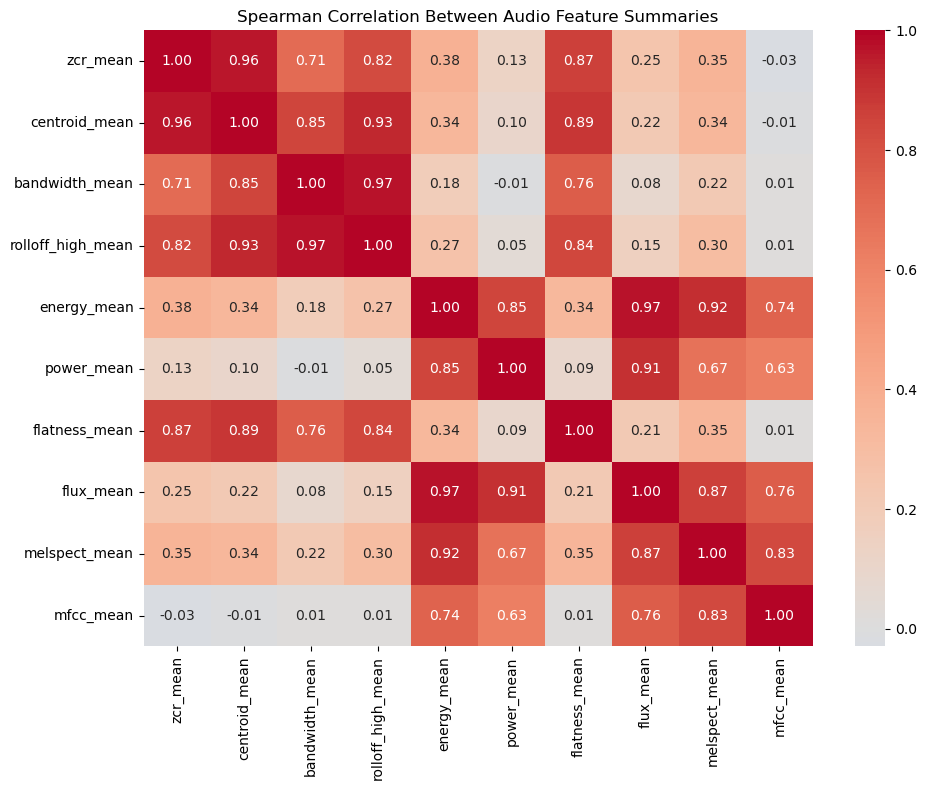

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Spearman Correlation Between Audio Feature Summaries")
plt.tight_layout()
plt.show()
